# Precipitation Model Testing Using ERA5 Data

This Jupyter Notebook tests a precipitation model using ERA5 reanalysis data as input.

The current version of the model requires the following meteorological inputs at each model time step:

#### Required Inputs

- **Surface Inputs** (from ERA5 Single Levels):
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature

- **Atmospheric Profile Inputs** (from ERA5 Pressure Levels):
  - Temperature at pressure levels
  - Specific humidity at pressure levels

These inputs are used to simulate the evolution of the model state, which is the  **Cloud column liquid water**, including:
- How it evolves over time
- How much is converted to rainwater
- How much reaches the ground as precipitation

To estimate precipitation, all of the above input variables must be provided at each timestep.

#### Data Sources

- **ERA5 Single Levels** (ECMWF): for 2m temperature, dew point, and surface pressure  
- **ERA5 Pressure Levels** (ECMWF): for vertical profiles of temperature and specific humidity

#### Data Preparation

The input datasets are preprocessed and combined externally using the notebook:

```bash
preparing_era_data.ipynb

In [92]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from physics_equations import specific_humidity_from_rh,w_sat
import profiles_and_cloud_heights_new as profiles
from constants import g,alpha
import interpolation_lcl as interp
from autoconversion_rate import thresh
import autoconversion_rate as ar
from entrainment_new import calculate_profiles_with_entrainment,lcl_enrtainment_from_ground
import condensation_fluxes
import updraft_emmanuel
import new_rainfall_scheme as nr
import top_outflow as outflow

## Table of Contents

1. [Loading the data](#Loading-the-data)
2. [Running the model](#Running-the-model)
3. [Visualizing the outputs](#Visualizing-the-outputs)


## Loading the data

Interactive cell for initializing the model settings. Choose the desired values, click Apply Settings and then Run All cells again or Run below.

In [93]:
%run widgets.py

The input data used in this model consist of a combined dataset derived from **ERA5 surface values** and **ERA5 atmospheric profiles**.

- **Surface variables** include:
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature
  - Specific humidity at the surface

- **Atmospheric profile variables** include:
  - Temperature at multiple pressure levels
  - Pressure levels
  - Specific humidity at those levels

After loading the dataset, only the data corresponding to the **desired time interval** are selected for further analysis.

In [94]:
data_era = xr.open_dataset(r'..\data\model_inputs\ERA5\ERA5combined_profile_data.nc')
data_era = data_era.sel(valid_time=slice(*slice_tuple))

if interp_interval != 'No':
    time_dim = 'valid_time'
    data_era_10min = data_era.resample({time_dim: interp_interval}).interpolate('linear')
    data_era = data_era_10min.sel(valid_time=slice(*slice_tuple))

Storing the time values and the timestep.

In [95]:
time = data_era.sel(valid_time=slice(*slice_tuple)).valid_time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Environmental profiles and inputs

The model inputs

In [96]:
T_air = data_era.temperature.values
p_air = data_era.pressure.values
Z = data_era.height.values
T_d = data_era.dew_point_temperature.values
q_v_air = data_era.specific_humidity.values      

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance.

In [97]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
#hourly_avg = rain_rate.resample(time='1H').mean()
hourly_acc = rain_rate.resample(time="5min").sum()

## Running the model

### Parcel Profiles

Store the sizes for creating empty arrays

In [98]:
rows = T_air.shape[0]
cols = T_air.shape[1]

#### Initializing Model Output Arrays

Empty arrays are created to store the outputs of the model. These arrays are initialized with dimensions either `(time, height)` or `(time)`, depending on the variable.

**Main Model Outputs**
- **`temp_parcel`**: The parcel temperature profile, computed by solving the model’s thermodynamic equations.
- **`T_v_moist`**: The virtual temperature profile of the parcel.
- **`q_v_parcel`**: The specific humidity profile of the parcel.

**LCL Parameters** 
- **`p_s`**: LCL pressure.
- **`T_s`**: LCL temperature.
- **`lcl_index`**: Index of the lifting condensation level (LCL) in the vertical profile.

**Expanded Environmental Profiles**
All other arrays are expanded to `(time, height + 1)` to later include the LCL values explicitly in the profiles. This ensures that the exact values of the meteorological variables at the LCL level are stored and used in calculations.


In [99]:
temp_parcel = np.zeros((T_air.shape))
p_s = np.zeros(rows)    #cloud base pressure (time)
T_s = np.zeros(rows)    #cloud base temperature (time)
lcl_index = np.zeros(rows) #lcl index (time)

## empty arrays for storing the interpolated profiles (time, height+1)
temp_parcel_new = np.zeros((rows,cols+1))  # new parcel temperature (time, height+1)
air_temp_new = np.zeros((rows,cols+1))   # new temperature profile (time, height+1)
p_new = np.zeros((rows,cols+1))         # new pressure profile (time, height+1)
q_v_new = np.zeros((rows,cols+1))       # new specific humidity profile (time, height+1)
Z_new = np.zeros((rows,cols+1))         # new height profile (time, height+1)

## empty arrays for storing the outputs
T_v_moist = np.zeros((rows,cols+1))
q_v_parcel = np.zeros((rows,cols+1))
Z_b = np.zeros(rows)


#### Implementing the Model: Temperature and Humidity Profiles

This section implements the model functions used to calculate the **parcel's temperature and humidity profiles**. For the temperature profile calculation, the user can select among several conserved quantity approaches:

- `'theta_e'` — Pseudoadiabatic equivalent potential temperature  
- `'theta_l'` — Reversible liquid water potential temperature  
- `'theta_e_reversible'` — Reversible equivalent potential temperature  
- `'GB84'` — Pseudoadiabatic equivalent potential temperature (as defined in Georgakakos and Bras, 1984a)

**Calculation Workflow**

1. *Parcel Temperature and LCL Variables*  
   Using the `profiles_and_cloud_heights.py` module, the parcel temperature profile is computed along with key LCL (Lifting Condensation Level) variables.

2. *Interpolation at the LCL* 
   The `interpolation_lcl.py` module is then used to interpolate both the parcel and environmental profiles so that all relevant meteorological variables are available at the exact height of the LCL.

3. *Parcel Humidity and Virtual Temperature* 
   Finally, with the updated profiles, `profiles_and_cloud_heights.py` is used again to calculate the parcel's specific humidity and virtual temperature profiles.



In [100]:
#import profiles_and_cloud_heights as profiles
#import interpolation_lcl as interp

for i in range(0,T_air.shape[0]):

    #calculating the profiles
    q_t = w_sat(T_d[i],p_air[i,0])
    temp_parcel[i,:],lcl_index[i],p_s[i],T_s[i] = profiles.calculate_parcel_Temp_profile(T_air[i,0],p_air[i,0],T_d[i],p_air[i],theta_type=theta_type)

    #interpolation at the lcl level
    temp_parcel_new[i], p_new[i], Z_new[i], lcl_index[i], air_temp_new[i], q_v_new[i] = interp.insert_lcl_values(temp_parcel[i],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])

    #calculating the virtual temperature profile of the parcel
    T_v_moist[i,:],q_v_parcel[i,:] = profiles.calculate_parcel_T_v_profile(T_d[i],p_new[i],temp_parcel_new[i,:],int(lcl_index[i]),theta_type=theta_type)

In [101]:
negs = (q_v_parcel < 0).sum()
print(f"Number of negative values in q_l_new: {negs}")

Number of negative values in q_l_new: 0


#### Calculate the environmental virtual temperature profiles

In [102]:
T_v_env = air_temp_new*(1+0.61*q_v_new)

### Cloud Heights

#### Determining the Location of the LFC

This step calculates the **Level of Free Convection (LFC)**, indicated by the `lfc_index`. The goal is to determine whether the parcel can reach the LFC based on its thermodynamic state.

- If the conditions allow the parcel to become positively buoyant and reach the LFC, the first entry of the `LFC_index` variable is marked as `"yes"` and a value of `1` is stored.
- If the parcel cannot reach the LFC, the entry is marked as `"no"` and a value of `0` is stored.

This check ensures the model accurately tracks whether convection is initiated in each timestep.


In [103]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc_level(
        T_v_moist[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

#### Determining the cloud top and cloud depth
Finding the **cloud top height** and **pressure** and the **resulting cloud depth**, again by calling `profiles_and_cloud_heights.py`.

In [104]:
#empty arrays for storing the outputs
Z_c = np.zeros(rows)
Z_t = np.zeros(rows)
p_t = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c[i],Z_t[i],p_t[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist[i],T_v_env[i],temp_parcel_new[i])

### Entrainment calculations

Cell that automatically selects the correct index of cloud height to implement entrainment from, based on the user selection

In [105]:
if entrainment_beginning=='from LCL':
    start_index = lcl_index + 1
elif entrainment_beginning=='from ground':
    start_index = np.ones(lcl_index.shape[0])

Updating the parcel profiles of temperature and humidity, this time taking entrainment into account 

In [106]:
#from profiles_and_cloud_heights import profiles_with_entrainment
T_parcel_new = np.zeros((rows,cols+1)) 
q_t_parcel_new = np.zeros((rows,cols+1))
Theta_air_arr = np.zeros((rows,cols+1))
q_l_new = np.zeros((rows,cols+1))
q_v_parcel_new = np.zeros((rows,cols+1))
for i in range(0,rows):
    #print(i)
    entrainment_rate = min(0.001,1/Z_c[i])     #Siebesma et al. (2003)
    T_parcel_new[i],q_t_parcel_new[i],q_l_new[i],q_v_parcel_new[i],Theta_air_arr[i] = calculate_profiles_with_entrainment(T_s[i], T_d[i], air_temp_new[i], temp_parcel_new[i], p_s[i], p_new[i], q_v_new[i], Z_new[i,], int(start_index[i]), entrainment_rate, theta_type)


In [107]:
# if entrainment starts from the ground, then the LCL changes so it has to be recalculated and interpolated
if entrainment_beginning=='from ground':

    for i in range(0,rows):
    #print(i)
        entrainment_rate = min(0.001,1/Z_c[i])     #Siebesma et al. (2003)
        
        temp_parcel[i] = np.delete(T_parcel_new[i],int(lcl_index[i]))
        p_air[i] = np.delete(p_new[i],int(lcl_index[i]))
        Z[i] = np.delete(Z_new[i],int(lcl_index[i]))
        T_air[i] = np.delete(air_temp_new[i],int(lcl_index[i]))
        q_v_air[i] = np.delete(q_v_new[i],int(lcl_index[i]))

        lcl_index[i],T_s[i],p_s[i] = lcl_enrtainment_from_ground(T_parcel_new[i],p_new[i],T_d[i],Z_new[i])
        lcl_index[i] = np.clip(int(lcl_index[i]), 0, len(p_air[i]) - 3)     #for cases where the LCL is in very high altitude

        #interpolation at the lcl level
        T_parcel_new[i], p_new[i], Z_new[i], lcl_index[i], air_temp_new[i], q_v_new[i] = interp.insert_lcl_values(temp_parcel[i],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])
    



Calculating the new parcel virtual temperature profile after considering entrainment 

In [108]:
if theta_type=='theta_e' or theta_type=='GB84':
    T_v_moist_new = T_parcel_new*(1+0.61*q_v_parcel_new)
else:
    T_v_moist_new = T_parcel_new*(1+0.61*q_v_parcel_new- q_l_new)

#### LFC height

Calculating the location of the LFC, which is given by the lfc_index, as well as if the conditions allow the parcel to reach it. If so, then the first value of the LFC_index variable will print "yes" and we are storing 1. Otherwise, we get "no" and 0 is stored.

In [109]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc_level(
        T_v_moist_new[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

#### Determining the cloud top and cloud depth
Finding the **cloud top height** and **pressure** and the **resulting cloud depth**, again by calling `profiles_and_cloud_heights.py`.

In [110]:
#empty arrays for storing the outputs
Z_c_new = np.zeros(rows)
Z_t_new = np.zeros(rows)
p_t_new = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c_new[i],Z_t_new[i],p_t_new[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist_new[i],T_v_env[i],T_parcel_new[i])

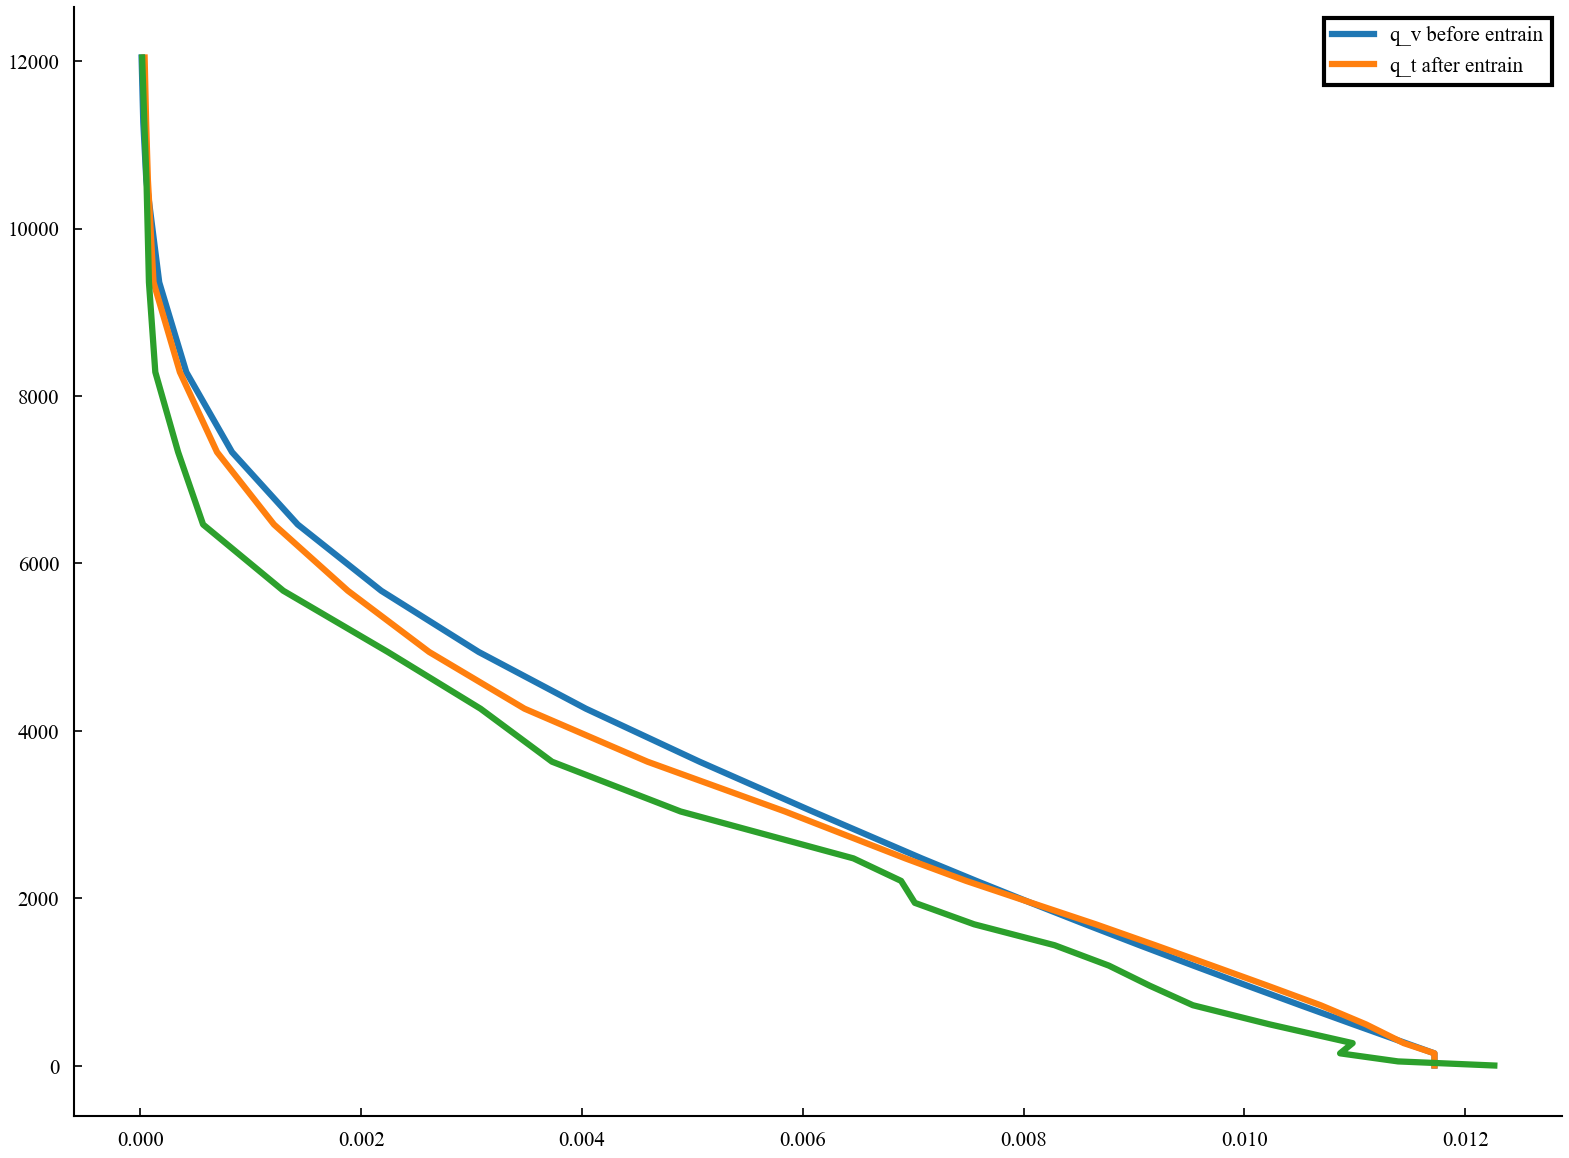

In [111]:
index = 2
plt.plot(q_v_parcel[index],Z_new[index],label='q_v before entrain')
#plt.plot(q_v_parcel[index],Z_new[index])
#plt.plot(q_v_new[index],Z_new[index])
plt.plot(q_v_parcel_new[index],Z_new[index],label='q_t after entrain')
plt.plot(q_v_new[index],Z_new[index])
#plt.plot(q_v_parcel_new[index],Z_new[index])
#plt.plot(q_l_new[index],Z_new[index])
#plt.axhline(y=Z_new[index,int(lcl_index[index+1])],color='blue')
#plt.axhline(y=Z_t[index],color='green')
#plt.axhline(y=Z_t_new[index],color='red')
plt.legend()
plt.show()

In [112]:
def find_top_index(Z_t_new,Z_c_new,Z_new):
    if Z_t_new == 0 or Z_c_new == 1:  
        top_index = 0
    else:
         top_index = np.argmax((Z_t_new - Z_new) <= 0)
    return top_index

### Updraft speed

Using the parcel and environmental virtual temperature profiles, we calculate the parcel **updraft velocity profile** by calling the `updraft_emmanuel.py`. To do so, we have to first find the index of cloud top height. 

In [113]:
#import updraft_emmanuel

w_parcel_max= np.zeros(rows)
for i in range(0,rows):
    top_index = find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i])
    w_parcel_max[i],CAPE = updraft_emmanuel.calculate_parcel_updraft_velocity(Z_new[i],T_v_moist_new[i],T_v_env[i],LFC_index[i,1],top_index)

In [114]:
n_nans = np.isnan(q_t_parcel_new).sum()
print(f"Number of NaNs in q_l_new: {n_nans}")

Number of NaNs in q_l_new: 0


### State calculation and update

#### Calculating the Temporal Evolution of the Cloud System

This section computes the **state evolution of the cloud system over time**. The evolution focuses on changes in cloud liquid water content due to condensation and precipitation processes.

**Components of the Moisture Budget**

- *Condensation (Inflow)*  
  The amount of condensed water within the cloud is calculated using the `GB84.py` module, based on the approach of Georgakakos and Bras (1984).

- *Outflow (Losses)*  
  Moisture outflow from the cloud includes:
  - *Rainwater formation*: Determined via the `autoconversion_rate.py` module, which estimates the rate at which cloud water is converted to rain.
  - *Droplet removal by updrafts*: Handled by the `top_outflow.py` module, representing the loss of cloud droplets entrained by upward-moving air.

Together, these components allow the model to track the cloud water budget and estimate precipitation over time.


In [115]:
#import autoconversion_rate as ar
#from GB84_eqs import f as flux, rho_m
#import top_outflow as outflow

#empty arrays for storing condensation flux and state values
f_arr = np.zeros(rows)
X =np.zeros(rows)


for i in range(0,rows):
    top_index = find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i])  

    w_avg = w_parcel_max[i]/2
    rho = condensation_fluxes.rho_m(T_s[i],T_parcel_new[i,top_index],p_s[i],p_t_new[i])
    if w_parcel_max[i] == 0:
        # no convection == no flux
        f_arr[i] = 0
    else:
        f_arr[i] = condensation_fluxes.condensation_flux(rho,w_avg,q_l_new[i],int(lcl_index[i]),top_index,theta_type=theta_type)

    if i<rows-1:
        #if X[i]/Z_c_new[i] > 2.5e-3:        #capping the X values so that they don't abnormally high
            #X[i] = 2.5e-3*Z_c_new[i]

    #state update
        X[i+1] = X[i] +f_arr[i]*dt_seconds[i] - ar.cloud_water_autoconversion_rate(X[i],Z_c_new[i],thresh)*dt_seconds[i]# - outflow.calculate_water_top_outflow(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        X[i+1] = max(0,X[i+1])

In [116]:
f_arr

array([0., 0., 0., ..., 0., 0., 0.])

In [117]:
total_water = np.zeros(rows)
for i in range(0,rows):
    top_index = find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i])
    if theta_type == "GB84" or theta_type == "theta_e":         #in pseudoadiabatic approach water is constantly removed, 
        total_water[i] = np.sum(q_l_new[i,int(lcl_index[i]):int(top_index)+1])                                                   #so integrate over all cloud heights
    
    else:                                                       #in reversible approach water is staying inside the parcel,
        total_water[i] = q_l_new[i,int(top_index)]                                                  #so total water is what reaches the cloud top

In [118]:
np.mean(total_water)

0.0012626370437222021

### Rainfall rates

#### Precipitation Rate Calculation at Ground Level

The process to calculate the precipitation rate reaching the ground involves multiple steps:

- **Rainfall Rate from Cloud:**  
   The initial rate of rainfall exiting the cloud is determined by executing the script `autoconversion_rate.py`.

- **Rain Droplet Size Distribution:**  
   Using the calculated rainfall rate, the script `new_rainfall_scheme.py` assumes and computes a raindrop size distribution.

- **Estimation of Surface Precipitation:**  
   Based on the droplet size distribution, the model estimates the fraction of raindrops that survive evaporation during their descent and subsequently reach the ground as precipitation.


In [119]:
#import autoconversion_rate as ar
#import new_rainfall_scheme as nr

# empty arrays for storing the rainfall rates and the size distribution parameters

R = np.zeros(rows)  #rainfall rate at the cloud base
P = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    #print(i)
    rho = condensation_fluxes.rho_m(T_s[i],T_parcel_new[i,top_index],p_s[i],p_t_new[i])
    w_avg = w_parcel_max[i]/2
    R[i] = ar.cloud_water_autoconversion_rate(X[i],Z_c_new[i],thresh)
    if R[i]<=2.7e-5:      #excluding precipitation rates below 0.1 mm/h due to numerical issues
        P[i] = 0
    else:
        Lambda_result = nr.solve_lambda_mu_dependent(R[i], alpha, w_avg*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        #print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(T_parcel_new[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c_new[i],w_avg*100).calculate_evaporation_critical_diameter()
        P[i] = nr.ground_precipitation_rate(R[i], mu_result, Lambda_result, D_critical*100,w_avg*100,alpha)

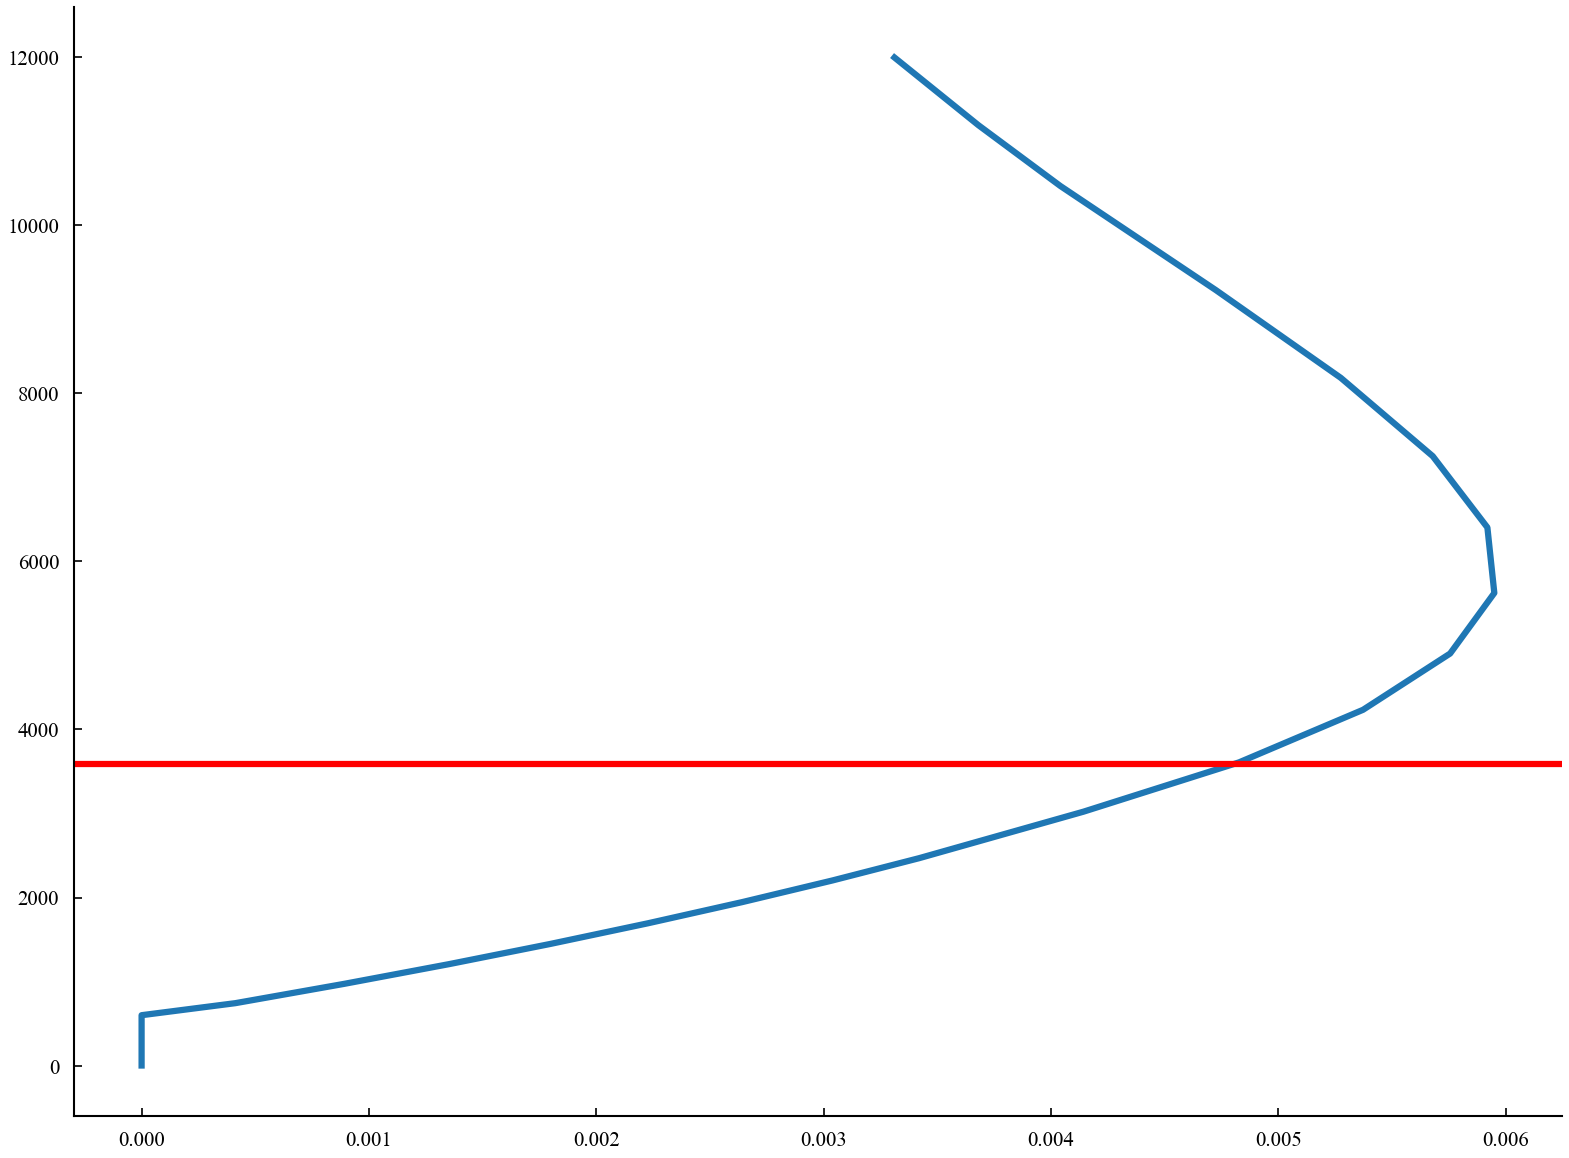

In [120]:
index_max = np.argmax(Z_t_new)
plt.plot(q_l_new[index_max],Z_new[index_max])
#plt.plot(q_v_parcel[index_max],Z_new[index_max])
#plt.plot(q_v_parcel_new[index_max],Z_new[index_max])
plt.axhline(y=Z_t_new[index_max],color='red')
#plt.axhline(y=Z_new[index_max,int(LFC_index[index_max,1])],color='green')
plt.show()

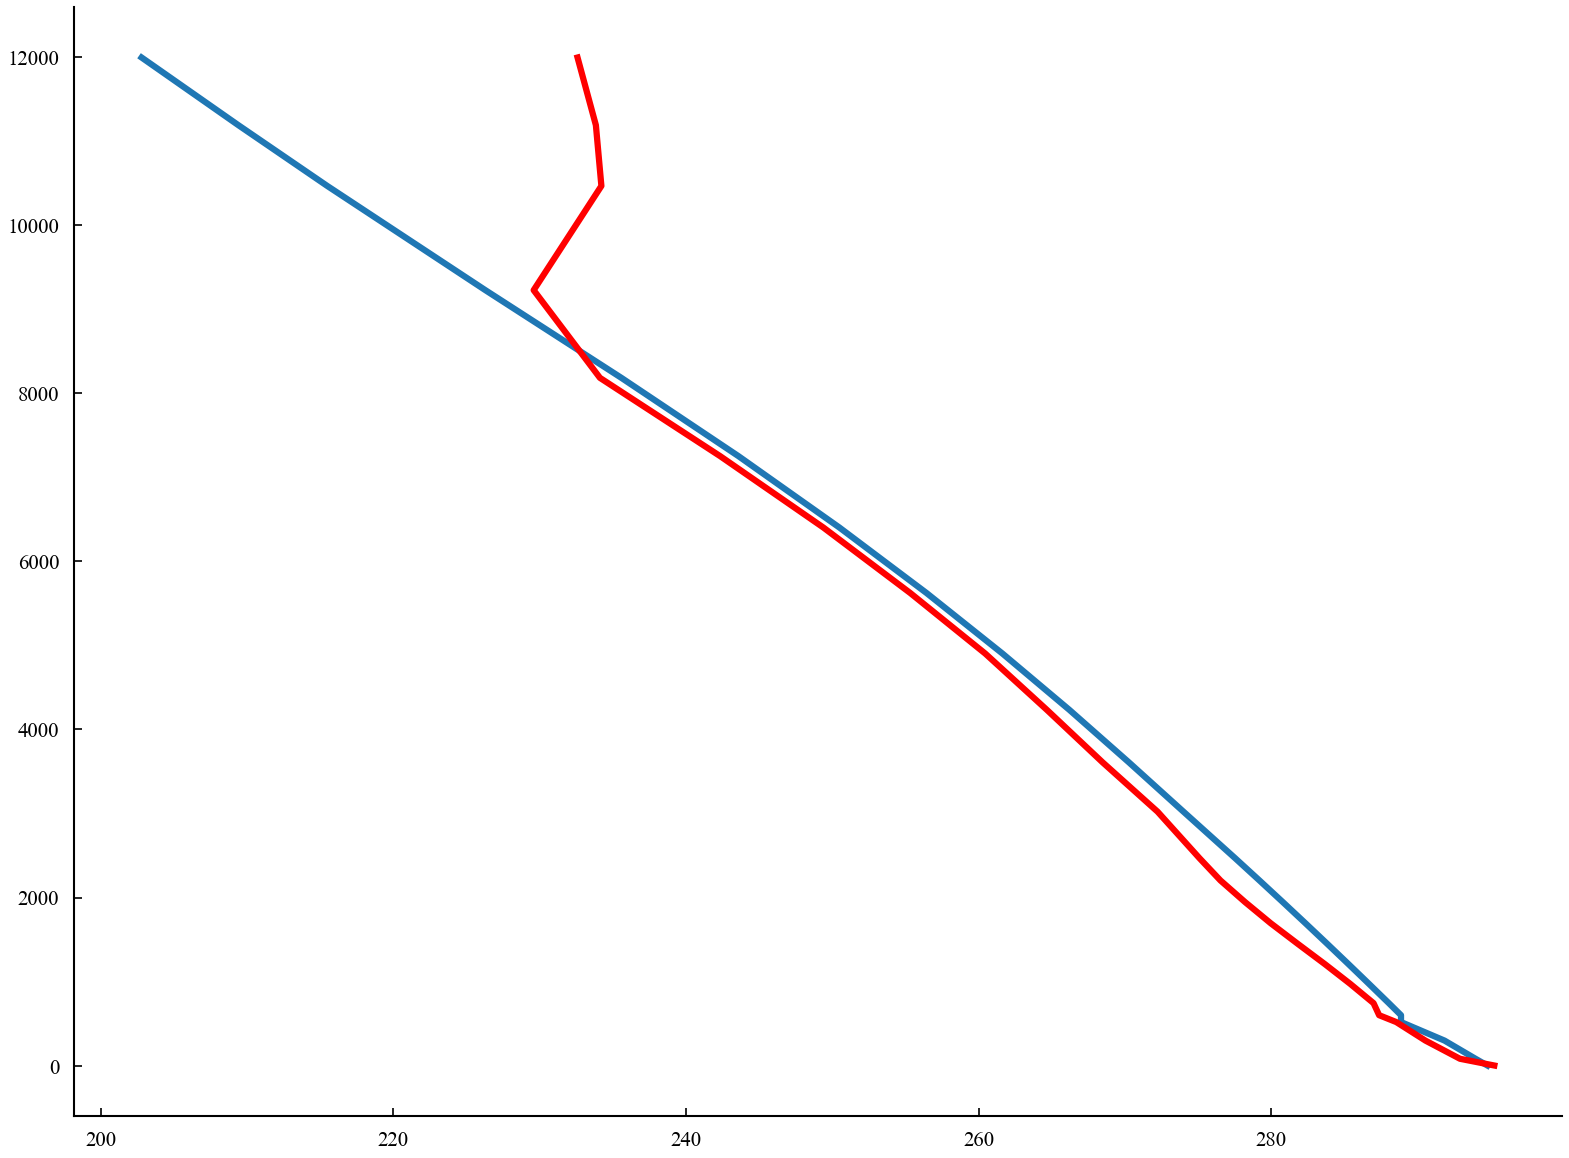

In [121]:
plt.plot(T_v_moist[index_max],Z_new[index_max])
#plt.plot(T_v_moist_new[index_max],Z_new[index_max])
plt.plot(T_v_env[index_max],Z_new[index_max],color='red')
plt.show()

## Visualizing the outputs

#### Rainfall rate

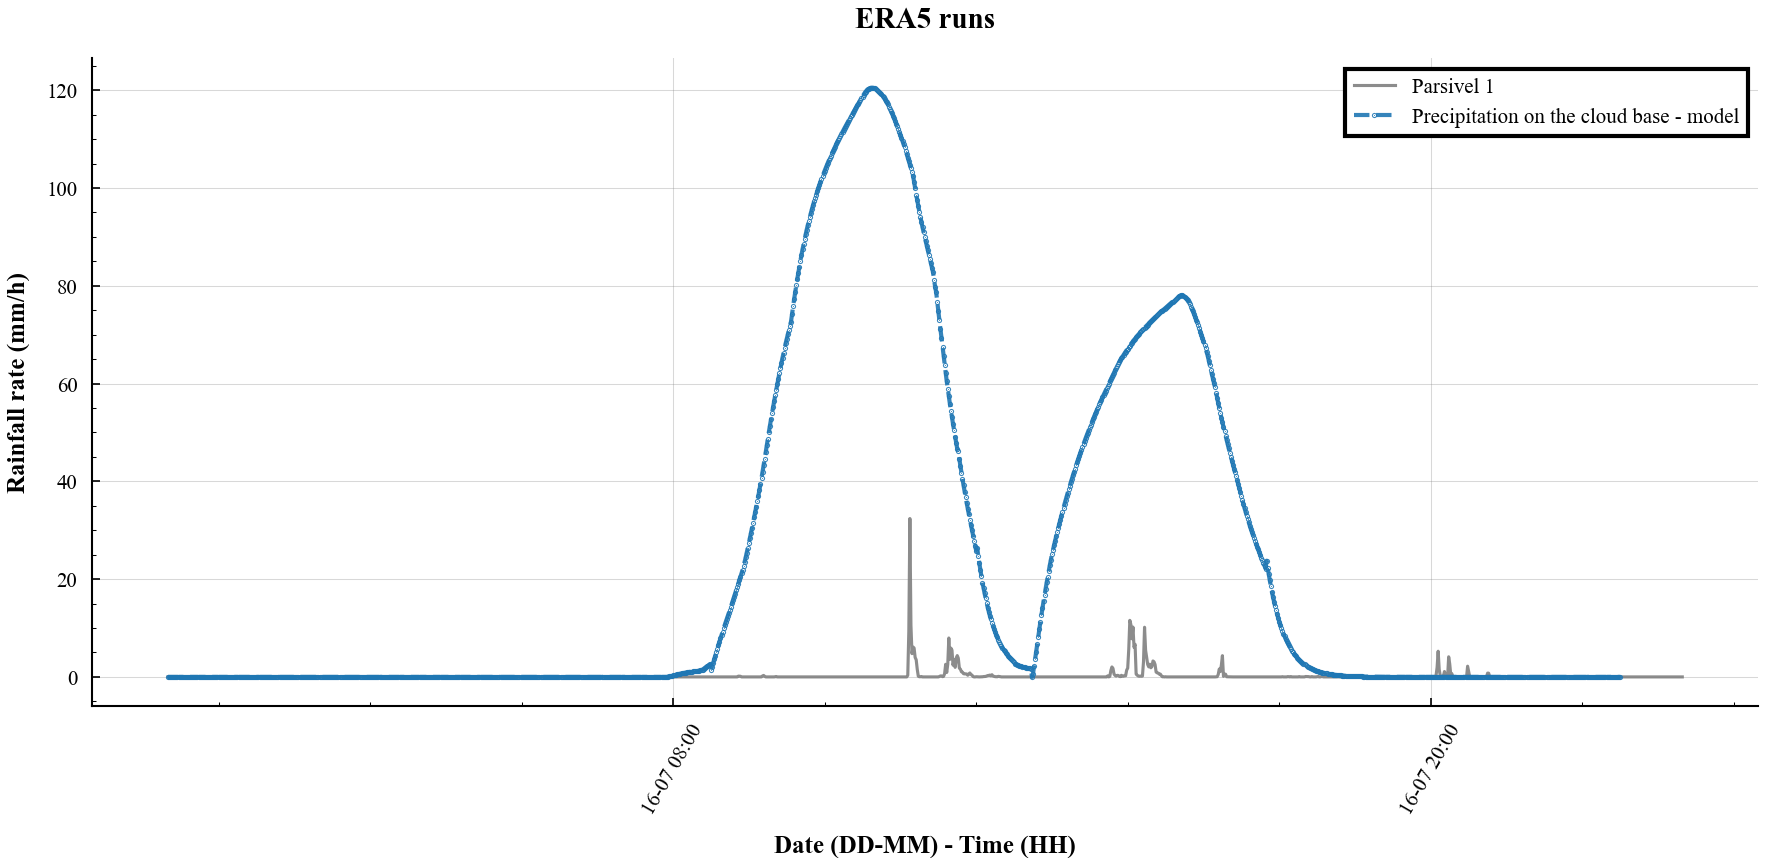

In [122]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'parsivel': '#808080',     # Grey
    'model': '#1f77b4',       # Blue
}

# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
#plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
line_parsivel = ax.plot(rain_rate.time, rain_rate, 
                       color=colors['parsivel'], 
                       label='Parsivel 1',
                       linewidth=1.5 * SCALE_FACTOR,
                       alpha=0.9)

line_model = ax.plot(time, R * 3600, 
                    color=colors['model'], 
                    linestyle='--', 
                    label='Precipitation on the cloud base - model',
                    linewidth=2.0 * SCALE_FACTOR,
                    marker='o',
                    markersize=0.5 * SCALE_FACTOR,
                    alpha=0.9)

#plt.plot(time,R_old*3600,color='red',linestyle='--',label='Precipitation on the ground - model')
#plt.plot(rain_rate.time[indexes_strat],rain_rate[indexes_strat],color='gray',label='Stratiform event')

# Scientific axis labels with units
ax.set_xlabel('Date (DD-MM) - Time (HH)', fontweight='bold')
ax.set_ylabel('Rainfall rate (mm/h)', fontweight='bold')
ax.set_title('ERA5 runs', fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Scientific legend positioning - scaled by SCALE_FACTOR
legend = ax.legend(loc='upper right',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=1 * SCALE_FACTOR,
                  ncol=1)

# Professional tick formatting
# Only apply scalar formatting to y-axis (rainfall rate)
ax.ticklabel_format(style='plain', axis='y')

# Ensure scientific notation if needed for y-axis only
from matplotlib.ticker import ScalarFormatter
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# For time axis, use proper date formatting - scale-aware
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor
if SCALE_FACTOR >= 1.0:
    tick_interval = 6  # Every 6 hours for full size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    tick_interval = 12  # Every 12 hours for medium size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    date_format = '%d-%m'  # Changed to d-m format for very small plots
    rotation = 45

ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=rotation, fontsize=10*SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

# Optional: Save with scientific filename convention
# plt.savefig(f'rainfall_rate_era5_entrainment.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')
#             format='pdf', dpi=600, bbox_inches='tight')

import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 1.0  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'hourly_avg': '#1f77b4',     # Blue
    'model': '#ff7f0e',          # Orange
}

# Plot with scaled line widths
ax.plot(time_dt, hourly_avg,
        color=colors['hourly_avg'], 
        label='Hourly average Parsivel 1',
        linewidth=2.0 * SCALE_FACTOR,
        alpha=0.9)

ax.plot(time_dt, R * 3600,
        color=colors['model'], 
        label='Model precipitation',
        linewidth=2.0 * SCALE_FACTOR,
        alpha=0.9)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Precipitation rate (mm/h)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Precipitation Comparison: Observations vs Model',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Improved legend - scaled spacing
legend = ax.legend(loc='upper right',
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

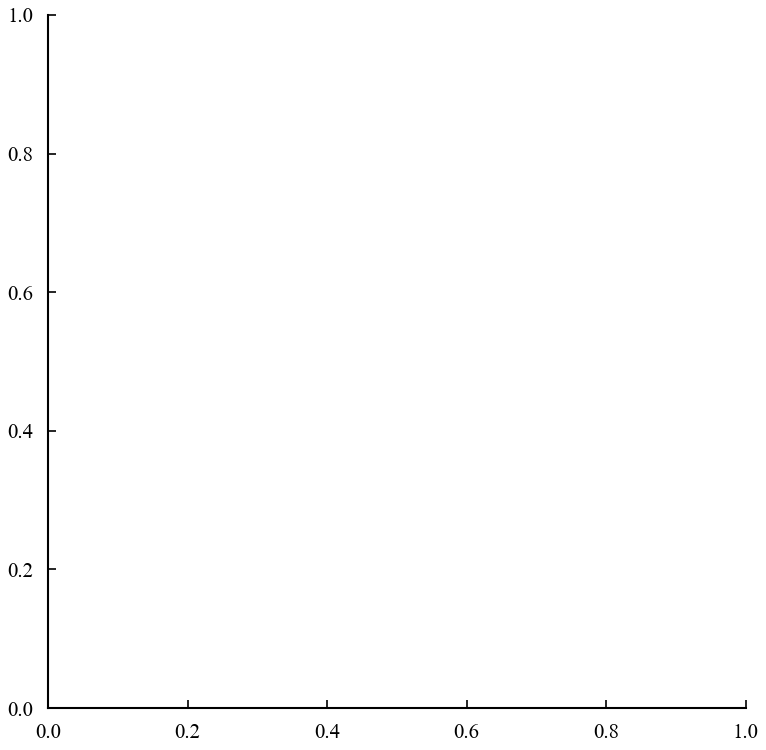

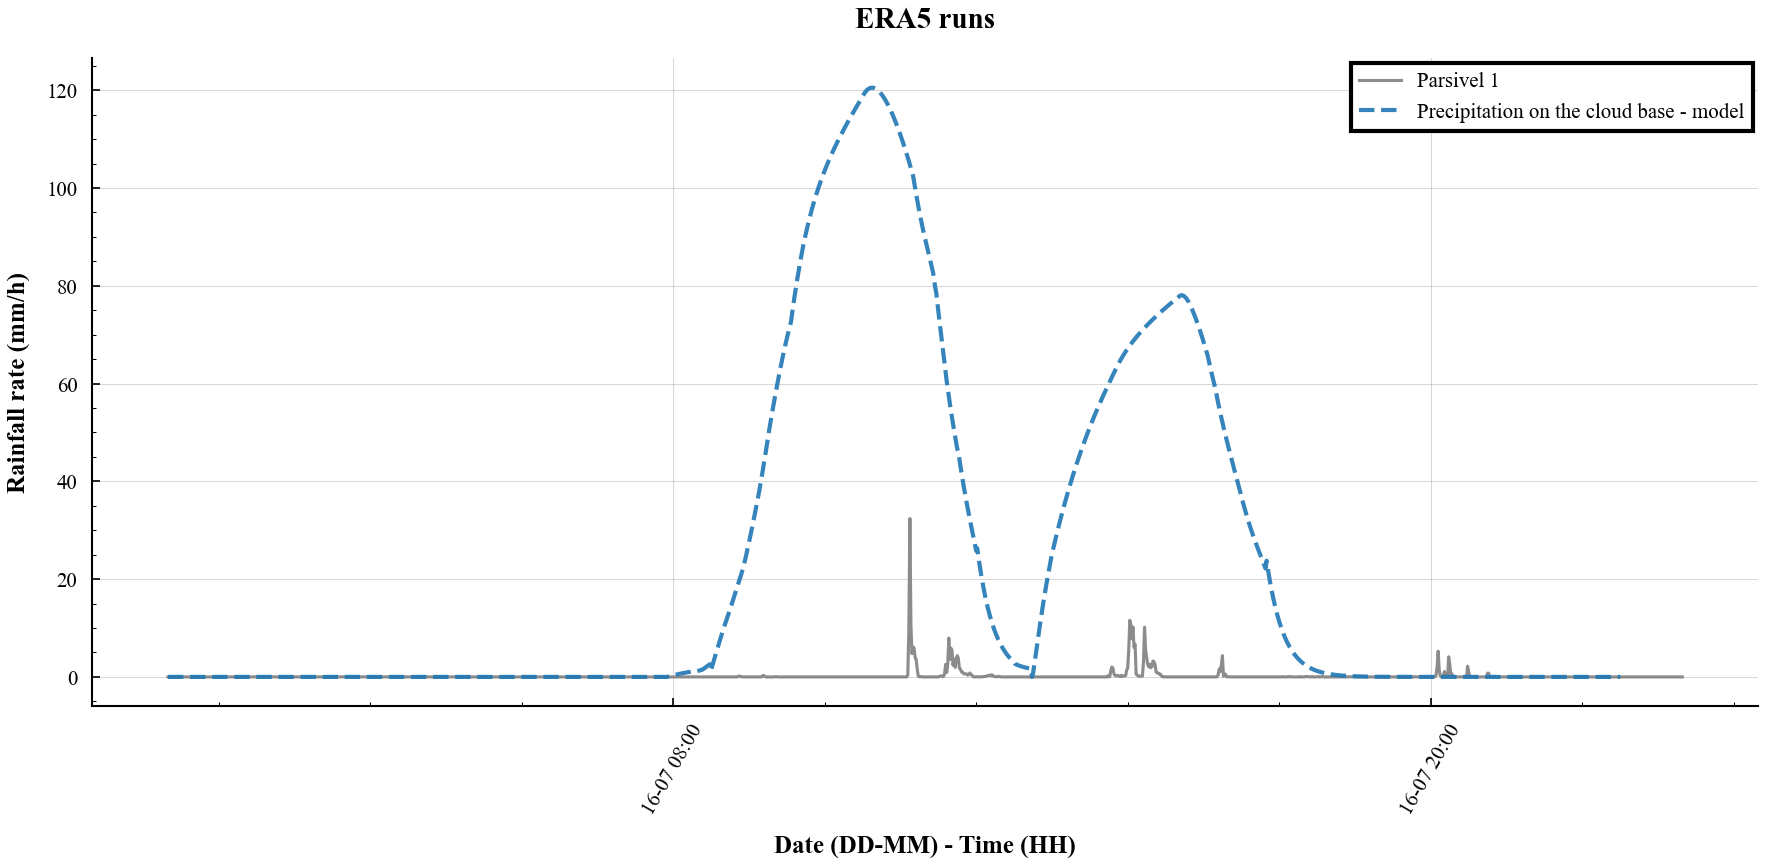

In [143]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'parsivel': '#808080',     # Grey
    'model': '#1f77b4',       # Blue
}

# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
#plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
line_parsivel = ax.plot(rain_rate.time, rain_rate, 
                       color=colors['parsivel'], 
                       label='Parsivel 1',
                       linewidth=1.5 * SCALE_FACTOR,
                       alpha=0.9)

line_model = ax.plot(time, R * 3600, 
                    color=colors['model'], 
                    linestyle='--', 
                    label='Precipitation on the cloud base - model',
                    linewidth=2.0 * SCALE_FACTOR,
                    alpha=0.9)

#plt.plot(time,R_old*3600,color='red',linestyle='--',label='Precipitation on the ground - model')
#plt.plot(rain_rate.time[indexes_strat],rain_rate[indexes_strat],color='gray',label='Stratiform event')

# Scientific axis labels with units
ax.set_xlabel('Date (DD-MM) - Time (HH)', fontweight='bold')
ax.set_ylabel('Rainfall rate (mm/h)', fontweight='bold')
ax.set_title('ERA5 runs', fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Scientific legend positioning - scaled by SCALE_FACTOR
legend = ax.legend(loc='upper right',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=0.5 * SCALE_FACTOR,
                  ncol=1)

# Professional tick formatting
# Only apply scalar formatting to y-axis (rainfall rate)
ax.ticklabel_format(style='plain', axis='y')

# Ensure scientific notation if needed for y-axis only
from matplotlib.ticker import ScalarFormatter
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# For time axis, use proper date formatting - scale-aware
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor
if SCALE_FACTOR >= 1.0:
    tick_interval = 6  # Every 6 hours for full size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    tick_interval = 12  # Every 12 hours for medium size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    date_format = '%d-%m'  # Changed to d-m format for very small plots
    rotation = 45

ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=rotation, fontsize=10*SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

# Optional: Save with scientific filename convention
# plt.savefig(f'rainfall_rate_era5_entrainment.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')
#             format='pdf', dpi=600, bbox_inches='tight')

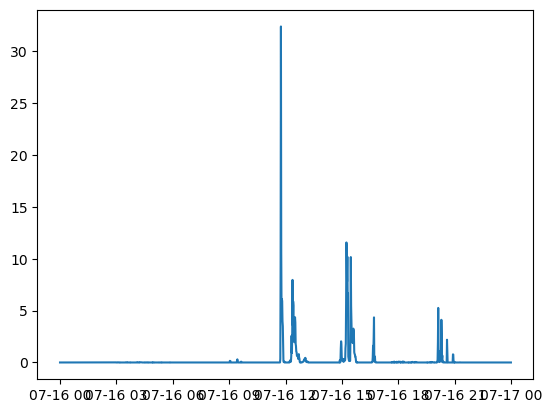

In [123]:
plt.plot(rain_rate.time, rain_rate)
plt.show()

#### Virtual Temperature profiles at different times

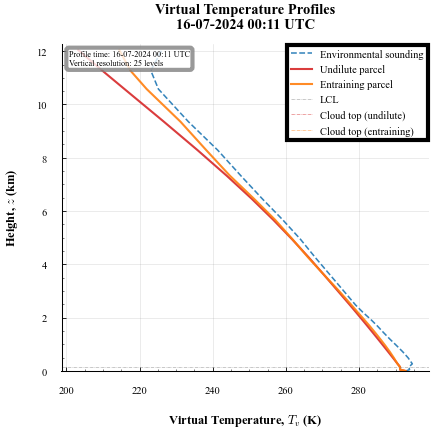

In [124]:
index_2 = 11
import pandas as pd
import numpy as np

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.25  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure with scientific aspect ratio - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(6 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'ambient': '#1f77b4',      # Blue
    'no_entrainment': '#d62728',  # Red  
    'with_entrainment': '#ff7f0e'  # Orange
}

# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_ambient = ax.plot(T_v_env[index_2], Z_new[index_2]/1000,  # Convert to km
                      color=colors['ambient'], 
                      label='Environmental sounding',
                      linestyle='--', 
                      linewidth=1.5 * SCALE_FACTOR,
                      alpha=0.9)

line_dry = ax.plot(T_v_moist[index_2], Z_new[index_2]/1000,
                  color=colors['no_entrainment'], 
                  label='Undilute parcel',
                  linestyle='-', 
                  linewidth=2.0 * SCALE_FACTOR,
                  alpha=0.9)

line_entrain = ax.plot(T_v_moist_new[index_2], Z_new[index_2]/1000,
                      color=colors['with_entrainment'], 
                      label='Entraining parcel',
                      linestyle='-', 
                      linewidth=2.0 * SCALE_FACTOR,
                      alpha=0.9)

# Scientific axis labels with units
ax.set_xlabel('Virtual Temperature, $T_v$ (K)', fontweight='bold')
ax.set_ylabel('Height, $z$ (km)', fontweight='bold')

# Format timestamp for title
timestamp_str = time_dt[index_2].strftime('%d-%m-%Y %H:%M UTC')
ax.set_title(f'Virtual Temperature Profiles\n{timestamp_str}',
             fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Add horizontal reference lines with labels - scaled line widths by SCALE_FACTOR
lcl_line = ax.axhline(y=Z_new[index_2,int(lcl_index[index_2])]/1000, 
                     color='grey', linestyle='-.', linewidth=0.5 * SCALE_FACTOR, alpha=0.8,
                     label='LCL')

zt_line = ax.axhline(y=Z_t[index_2]/1000, 
                    color=colors['no_entrainment'], linestyle='-.', linewidth=0.5 * SCALE_FACTOR, alpha=0.8,
                    label='Cloud top (undilute)')

zt_new_line = ax.axhline(y=Z_t_new[index_2]/1000, 
                        color=colors['with_entrainment'], linestyle='-.', linewidth=0.5 * SCALE_FACTOR, alpha=0.8,
                        label='Cloud top (entraining)')

# Set axis limits with some padding for scientific presentation
temp_range = [np.min([T_v_env[index_2].min(), T_v_moist[index_2].min(), T_v_moist_new[index_2].min()]),
              np.max([T_v_env[index_2].max(), T_v_moist[index_2].max(), T_v_moist_new[index_2].max()])]
temp_padding = (temp_range[1] - temp_range[0]) * 0.05
ax.set_xlim(temp_range[0] - temp_padding, temp_range[1] + temp_padding)

height_max = Z_new[index_2].max()/1000
ax.set_ylim(0, height_max * 1.02)

# Scientific legend positioning - now includes horizontal lines
legend = ax.legend(loc='upper right',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=0.5 * SCALE_FACTOR,
                  ncol=1)  # Single column for cleaner look

# Add subtle background for better contrast
#ax.set_facecolor('#fafafa')

# Professional tick formatting
ax.ticklabel_format(style='plain', axis='x')
ax.ticklabel_format(style='plain', axis='y')

# Ensure scientific notation if needed
from matplotlib.ticker import ScalarFormatter
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

plt.tight_layout()

# Optional: Add metadata text box for scientific context - scaled font size
textstr = f'Profile time: {timestamp_str}\nVertical resolution: {len(Z_new[index_2])} levels'
props = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=8 * SCALE_FACTOR,
        verticalalignment='top', bbox=props)

# Show the plot
plt.show()
# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)
# Optional: Save with scientific filename convention
# plt.savefig(f'virtual_temperature_profiles_{timestamp_str.replace(" ", "_").replace(":", "")}.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')

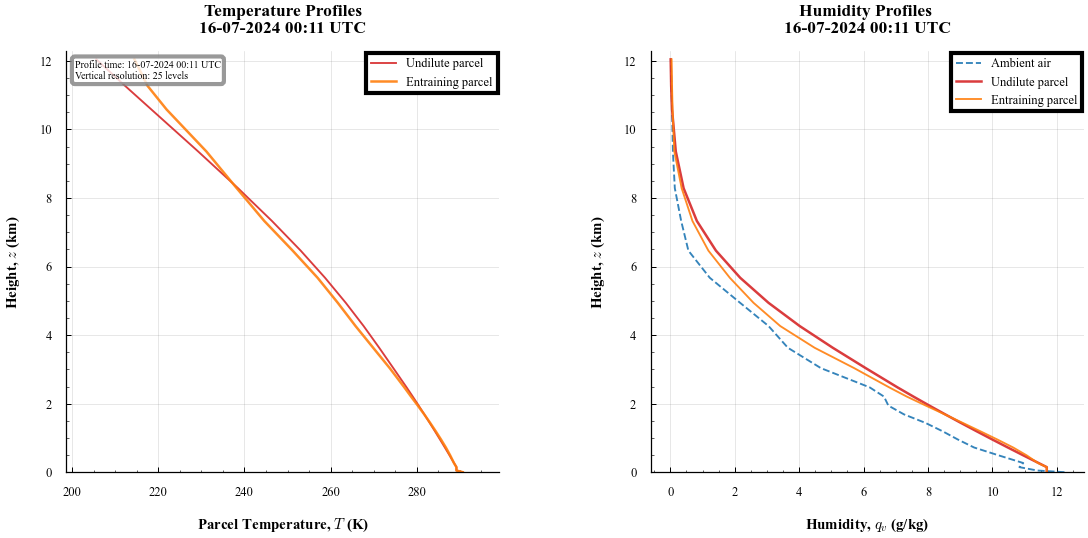

In [125]:
index_2 = 11
import pandas as pd
import numpy as np

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.3  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure with two subplots side by side - scaled by SCALE_FACTOR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'ambient': '#1f77b4',      # Blue
    'no_entrainment': '#d62728',  # Red  
    'with_entrainment': '#ff7f0e'  # Orange
}

# Format timestamp for title
timestamp_str = time_dt[index_2].strftime('%d-%m-%Y %H:%M UTC')

# ===== LEFT SUBPLOT (ax1) =====
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_ambient1 = ax1.plot(temp_parcel_new[index_2], Z_new[index_2]/1000,  # Convert to km
                        color=colors['no_entrainment'], 
                        label='Undilute parcel', 
                        linewidth=1.5 * SCALE_FACTOR,
                        alpha=0.9)

line_dry1 = ax1.plot(T_parcel_new[index_2], Z_new[index_2]/1000,
                    color=colors['with_entrainment'], 
                    label='Entraining parcel',
                    linewidth=2.0 * SCALE_FACTOR,
                    alpha=0.9)

# Scientific axis labels with units
ax1.set_xlabel('Parcel Temperature, $T$ (K)', fontweight='bold')
ax1.set_ylabel('Height, $z$ (km)', fontweight='bold')
ax1.set_title(f'Temperature Profiles\n{timestamp_str}',
              fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax1.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()

# Set axis limits with some padding for scientific presentation
temp_range1 = [np.min([T_v_env[index_2].min(), T_v_moist[index_2].min(), T_v_moist_new[index_2].min()]),
               np.max([T_v_env[index_2].max(), T_v_moist[index_2].max(), T_v_moist_new[index_2].max()])]
temp_padding1 = (temp_range1[1] - temp_range1[0]) * 0.05
ax1.set_xlim(temp_range1[0] - temp_padding1, temp_range1[1] + temp_padding1)

height_max1 = Z_new[index_2].max()/1000
ax1.set_ylim(0, height_max1 * 1.02)

# Scientific legend positioning - scaled by SCALE_FACTOR
legend1 = ax1.legend(loc='upper right',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5 * SCALE_FACTOR,
                    ncol=1)

# ===== RIGHT SUBPLOT (ax2) - Duplicate =====
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_ambient2 = ax2.plot(1000*q_v_new[index_2], Z_new[index_2]/1000,  # Convert to km
                        color=colors['ambient'], 
                        label='Ambient air',
                        linestyle='--', 
                        linewidth=1.5 * SCALE_FACTOR,
                        alpha=0.9)

line_dry2 = ax2.plot(1000*q_v_parcel[index_2], Z_new[index_2]/1000,
                    color=colors['no_entrainment'], 
                    label='Undilute parcel',
                    linestyle='-', 
                    linewidth=2.0 * SCALE_FACTOR,
                    alpha=0.9)

line_moist = ax2.plot(1000*q_v_parcel_new[index_2], Z_new[index_2]/1000,  # Convert to km
                        color=colors['with_entrainment'], 
                        label='Entraining parcel',
                        linestyle='-', 
                        linewidth=1.5 * SCALE_FACTOR,
                        alpha=0.9)

# Scientific axis labels with units
ax2.set_xlabel('Humidity, $q_v$ (g/kg)', fontweight='bold')
ax2.set_ylabel('Height, $z$ (km)', fontweight='bold')
ax2.set_title(f'Humidity Profiles \n{timestamp_str}',
              fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax2.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax2.set_axisbelow(True)

# Minor ticks for precision
ax2.minorticks_on()

# Add horizontal reference lines with labels

height_max2 = Z_new[index_2].max()/1000
ax2.set_ylim(0, height_max2 * 1.02)

# Scientific legend positioning - scaled by SCALE_FACTOR
legend2 = ax2.legend(loc='upper right',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5 * SCALE_FACTOR,
                    ncol=1)

# Professional tick formatting for both subplots
for ax in [ax1, ax2]:
    ax.ticklabel_format(style='plain', axis='x')
    ax.ticklabel_format(style='plain', axis='y')
    
    # Ensure scientific notation if needed
    from matplotlib.ticker import ScalarFormatter
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# Adjust spacing manually instead of tight_layout to preserve subplot spacing
plt.subplots_adjust(left=0.08, right=0.95, top=0.9, bottom=0.12, wspace=0.35)

# Optional: Add metadata text box for scientific context - only on left subplot, scaled font size
textstr = f'Profile time: {timestamp_str}\nVertical resolution: {len(Z_new[index_2])} levels'
props = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=8 * SCALE_FACTOR,
         verticalalignment='top', bbox=props)

# Show the plot
plt.show()
# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)
# Optional: Save with scientific filename convention
# plt.savefig(f'virtual_temperature_profiles_{timestamp_str.replace(" ", "_").replace(":", "")}.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')

#### Cloud top and base

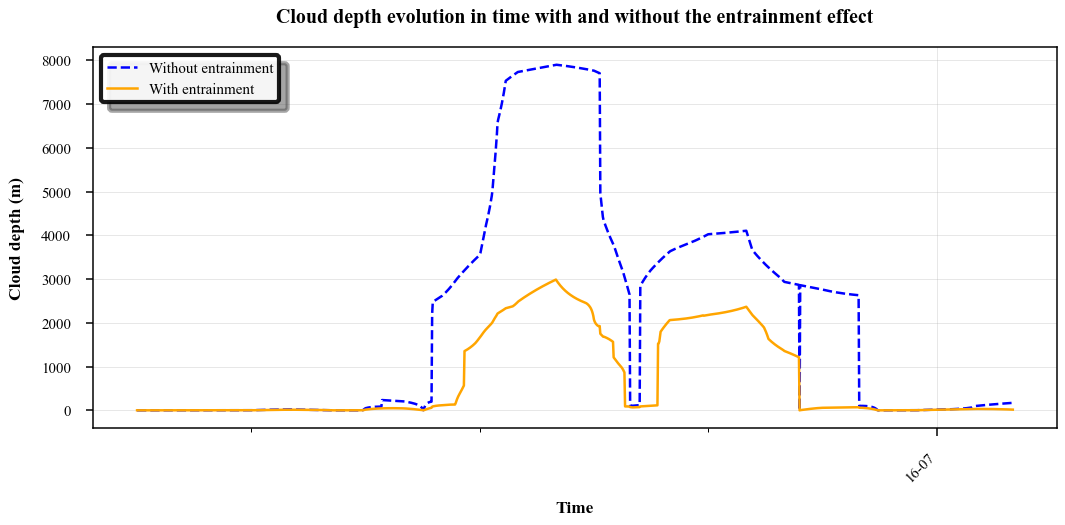

In [126]:
import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.3  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Plot with scaled line widths
ax.plot(time_dt, np.maximum(0, Z_t - Z_new[np.arange(Z_new.shape[0]), lcl_index.astype(int)]),
        color='blue', 
        label='Without entrainment',
        linestyle='--',
        linewidth=2.0 * SCALE_FACTOR)

ax.plot(time_dt, np.maximum(0, Z_t_new - Z_new[np.arange(Z_new.shape[0]), lcl_index.astype(int)]),
        color='orange', 
        label='With entrainment',
        linewidth=2.0 * SCALE_FACTOR)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Cloud depth (m)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Cloud depth evolution in time with and without the entrainment effect',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Improved legend - scaled spacing
legend = ax.legend(loc='upper left',
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

#### Updraft velocity

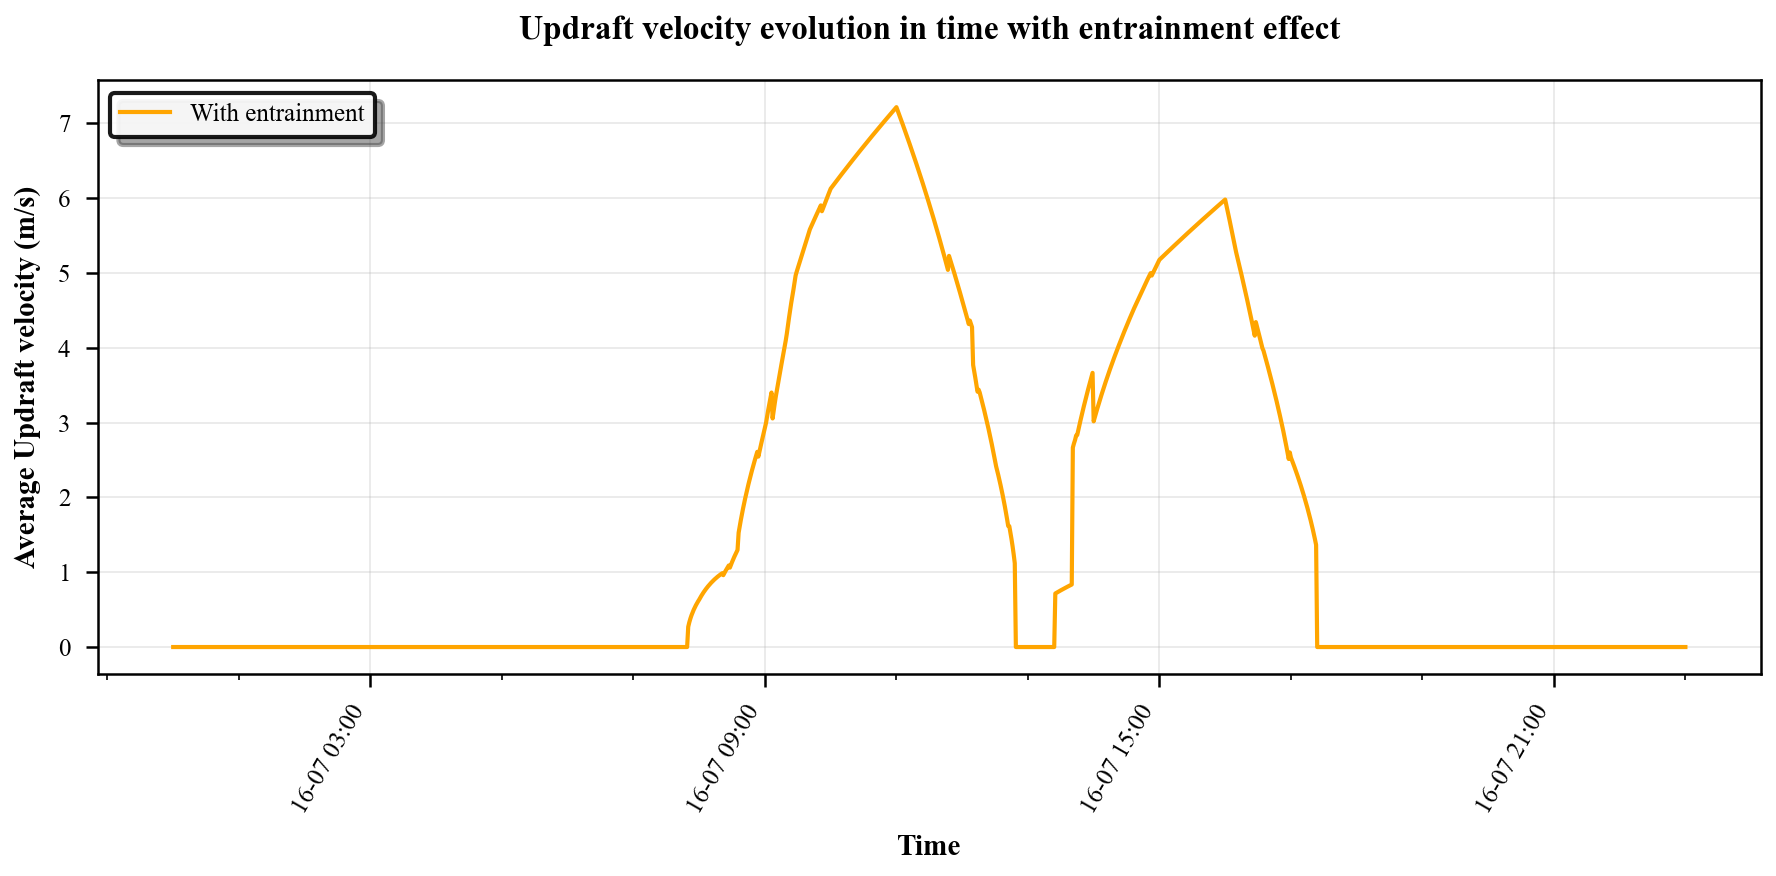

In [127]:
import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Plot with scaled line widths
#ax.plot(time_dt, w_parcel_max_old/2,
#        color='blue', label='Without entrainment', linestyle='--', 
#        linewidth=2.0 * SCALE_FACTOR)

ax.plot(time_dt, w_parcel_max/2,
        color='orange', 
        label='With entrainment',
        linewidth=2.0 * SCALE_FACTOR)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Average Updraft velocity (m/s)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Updraft velocity evolution in time with entrainment effect',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Improved legend - scaled spacing
legend = ax.legend(loc='upper left',
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

In [128]:
indices = np.where(R*3600>0.2)[0]
np.mean(w_parcel_max[indices]/2)

3.4724862548383295

In [129]:
len(X)

1381

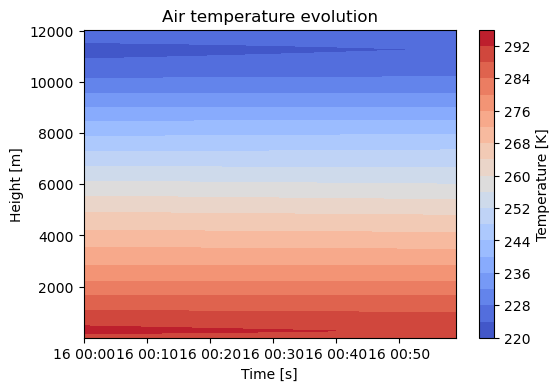

In [130]:

T, Zgrid = np.meshgrid(time[:60], Z_new[0])  # build 2D grid
plt.figure(figsize=(6,4))
cp = plt.contourf(T, Zgrid, air_temp_new[:60,:].T, levels=20, cmap="coolwarm")

plt.colorbar(cp, label="Temperature [K]")
plt.xlabel("Time [s]")
plt.ylabel("Height [m]")
plt.title("Air temperature evolution")
plt.show()


In [131]:
index = np.where(f_arr>0)
f_arr_mean = np.mean(f_arr[index])
#np.mean(q_l_new[index,int(lcl_index[index]):int(find_top_index(Z_new[index],lcl_index[index]))])

In [132]:
Z_c_new[8]

1.0

In [133]:
index = np.where(Z_c>1)
Z_c_mean = np.mean(Z_c[index])

In [134]:
np.where(X>0)

(array([ 471,  472,  473,  474,  475,  476,  477,  478,  479,  480,  481,
         482,  483,  484,  485,  486,  487,  488,  489,  490,  491,  492,
         493,  494,  495,  496,  497,  498,  499,  500,  501,  502,  503,
         504,  505,  506,  507,  508,  509,  510,  511,  512,  513,  514,
         515,  516,  517,  518,  519,  520,  521,  522,  523,  524,  525,
         526,  527,  528,  529,  530,  531,  532,  533,  534,  535,  536,
         537,  538,  539,  540,  541,  542,  543,  544,  545,  546,  547,
         548,  549,  550,  551,  552,  553,  554,  555,  556,  557,  558,
         559,  560,  561,  562,  563,  564,  565,  566,  567,  568,  569,
         570,  571,  572,  573,  574,  575,  576,  577,  578,  579,  580,
         581,  582,  583,  584,  585,  586,  587,  588,  589,  590,  591,
         592,  593,  594,  595,  596,  597,  598,  599,  600,  601,  602,
         603,  604,  605,  606,  607,  608,  609,  610,  611,  612,  613,
         614,  615,  616,  617,  618, 

In [135]:
time[8]

<xarray.DataArray 'valid_time' ()> Size: 8B
array('2024-07-16T00:08:00.000000000', dtype='datetime64[ns]')
Coordinates:
    latitude    float64 8B 52.0
    longitude   float64 8B 5.0
    number      int64 8B 0
    valid_time  datetime64[ns] 8B 2024-07-16T00:08:00
Attributes:
    long_name:      time
    standard_name:  time

In [136]:
a_autoconversion = 0.001
def X_series_1(f_arr_mean,X0,n,dt_time):
    
    #if X0 < thresh*Z_c_mean:
    X_n = X0 + n*f_arr_mean*dt_time
    return X_n

def X_series_2(Z_c_mean,f_arr_mean,X0,n,dt_time):
    X_n = (1-a_autoconversion*dt_time)**n * X0 + (f_arr_mean/a_autoconversion + thresh*Z_c_mean)*(1 - (1-a_autoconversion*dt_time)**(n))
    return X_n

In [137]:
n = 60
X_n_series = np.zeros([4,n])

X_0 = X[8]  # initial state at 8:00
#X_n_series_9 = np.zeros(n)
#X_n_series_9[0] = X_0
j = 0  # counter since last regime reset
X_n_series[0][0] = X_0
for a in range(4):
    if a>0:
        X_n_series[a][0] = X_n_series[a-1][-1]
    for i in range(1, n):
        j += 1
    
        if X_n_series[a][i-1] < thresh * Z_c_new[a+8]:
            print(j)
            # Non-precipitating branch
            X_n = X_series_1(f_arr[a+8], X_0, j, 60)
            X_n = max(0, X_n)
        # If threshold crossed -> reset
            if X_n >= thresh * Z_c_new[a+8]:
                X_0 = X_n
                j = 0
    
        else:
            # Precipitating branch
        
            X_n = X_series_2(Z_c_new[a+8], f_arr[a+8], X_0, j, 60)
            print(X_n)
            X_n = max(0, X_n)
            # If it drops below threshold -> reset
            if X_n < thresh * Z_c_new[a+8]:
                X_0 = X_n
                j = 0
        
        X_n_series[a][i] = X_n

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236


In [138]:
X_n_final = X_series_2(Z_c_new[12], f_arr[12], X_n_series[-1,-1], 1, 60)
X_n_final

3.0000000000000028e-05

In [139]:
X_n_series[0,-1]

0.0

In [140]:
X[9]

0.0

In [141]:
time_downscale = rain_rate.time.sel(time=slice('2024-07-16T08:00:00.000000000','2024-07-16T12:00:00.000000000'))

In [142]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)
# Example: every hour instead of every 3 hours
tick_interval = 1.0   # major ticks every hour
minor_interval = 0.5  # minor ticks every 30 minutes
# Create figure with scientific aspect ratio - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(6 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'ambient': '#1f77b4',      # Blue
    'no_entrainment': '#d62728',  # Red  
    'with_entrainment': '#ff7f0e'  # Orange
}

# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_model= ax.plot(time_downscale[:-1],ratio_series.reshape(-1),  # Convert to km
                      color=colors['ambient'], 
                      label='1min time step',
                      linestyle='--',
                      marker = 'o',
                      markersize = 0.5, 
                      linewidth=1.5 * SCALE_FACTOR,
                      alpha=0.9)

line_downscaled = ax.plot(time[8:13],X[8:13]/Z_c_new[8:13]*1000,
                  color=colors['no_entrainment'], 
                  label='1hr time step',
                  linestyle='-', 
                  marker = 'o',
                  markersize = 1, 
                  linewidth=2.0 * SCALE_FACTOR,
                  alpha=0.9)



# Scientific axis labels with units
ax.set_xlabel('Virtual Temperature, $T_v$ (K)', fontweight='bold')
ax.set_ylabel('Cloud water, $X$ (kg/m2)', fontweight='bold')

# Format timestamp for title
timestamp_str = time_dt[index_2].strftime('%d-%m-%Y %H:%M UTC')
ax.set_title(f'Virtual Temperature Profiles\n{timestamp_str}',
             fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Add horizontal reference lines with labels - scaled line widths by SCALE_FACTOR


# Scientific legend positioning - now includes horizontal lines
legend = ax.legend(loc='upper left',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=0.5 * SCALE_FACTOR,
                  ncol=1)  # Single column for cleaner look

# Add subtle background for better contrast
#ax.set_facecolor('#fafafa')

# Professional tick formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))

# Minor ticks every 30 minutes
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=30))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('LWC (g/m³)', fontweight='bold')
ax.set_xlabel('Date - Time', fontweight='bold')
ax.set_title('Cloud Water Content Evolution',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Optional: Uncomment to set y-axis limits
#ax.set_ylim(0, 10)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

NameError: name 'ratio_series' is not defined

In [ ]:
R_n_series = np.zeros(len(X_n_series.reshape(-1)))
for i in range(len(X_n_series.reshape(-1))):
    #j = i%60
    a = 8 + i//60
    #if j == 0:
    p = i - 60*((i//60))
    print(a,p)
    R_n_series[i] = ar.cloud_water_autoconversion_rate(X_n_series[a-8,p],Z_c_new[a],thresh)

8 0
8 1
8 2
8 3
8 4
8 5
8 6
8 7
8 8
8 9
8 10
8 11
8 12
8 13
8 14
8 15
8 16
8 17
8 18
8 19
8 20
8 21
8 22
8 23
8 24
8 25
8 26
8 27
8 28
8 29
8 30
8 31
8 32
8 33
8 34
8 35
8 36
8 37
8 38
8 39
8 40
8 41
8 42
8 43
8 44
8 45
8 46
8 47
8 48
8 49
8 50
8 51
8 52
8 53
8 54
8 55
8 56
8 57
8 58
8 59
9 0
9 1
9 2
9 3
9 4
9 5
9 6
9 7
9 8
9 9
9 10
9 11
9 12
9 13
9 14
9 15
9 16
9 17
9 18
9 19
9 20
9 21
9 22
9 23
9 24
9 25
9 26
9 27
9 28
9 29
9 30
9 31
9 32
9 33
9 34
9 35
9 36
9 37
9 38
9 39
9 40
9 41
9 42
9 43
9 44
9 45
9 46
9 47
9 48
9 49
9 50
9 51
9 52
9 53
9 54
9 55
9 56
9 57
9 58
9 59
10 0
10 1
10 2
10 3
10 4
10 5
10 6
10 7
10 8
10 9
10 10
10 11
10 12
10 13
10 14
10 15
10 16
10 17
10 18
10 19
10 20
10 21
10 22
10 23
10 24
10 25
10 26
10 27
10 28
10 29
10 30
10 31
10 32
10 33
10 34
10 35
10 36
10 37
10 38
10 39
10 40
10 41
10 42
10 43
10 44
10 45
10 46
10 47
10 48
10 49
10 50
10 51
10 52
10 53
10 54
10 55
10 56
10 57
10 58
10 59
11 0
11 1
11 2
11 3
11 4
11 5
11 6
11 7
11 8
11 9
11 10
11 11
11 12
11

In [ ]:
X_n_series[0] - thresh*Z_c_new[8]

array([-0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005])

In [ ]:
X_n_series.reshape(-1)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [ ]:
R_n_series.reshape(-1)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

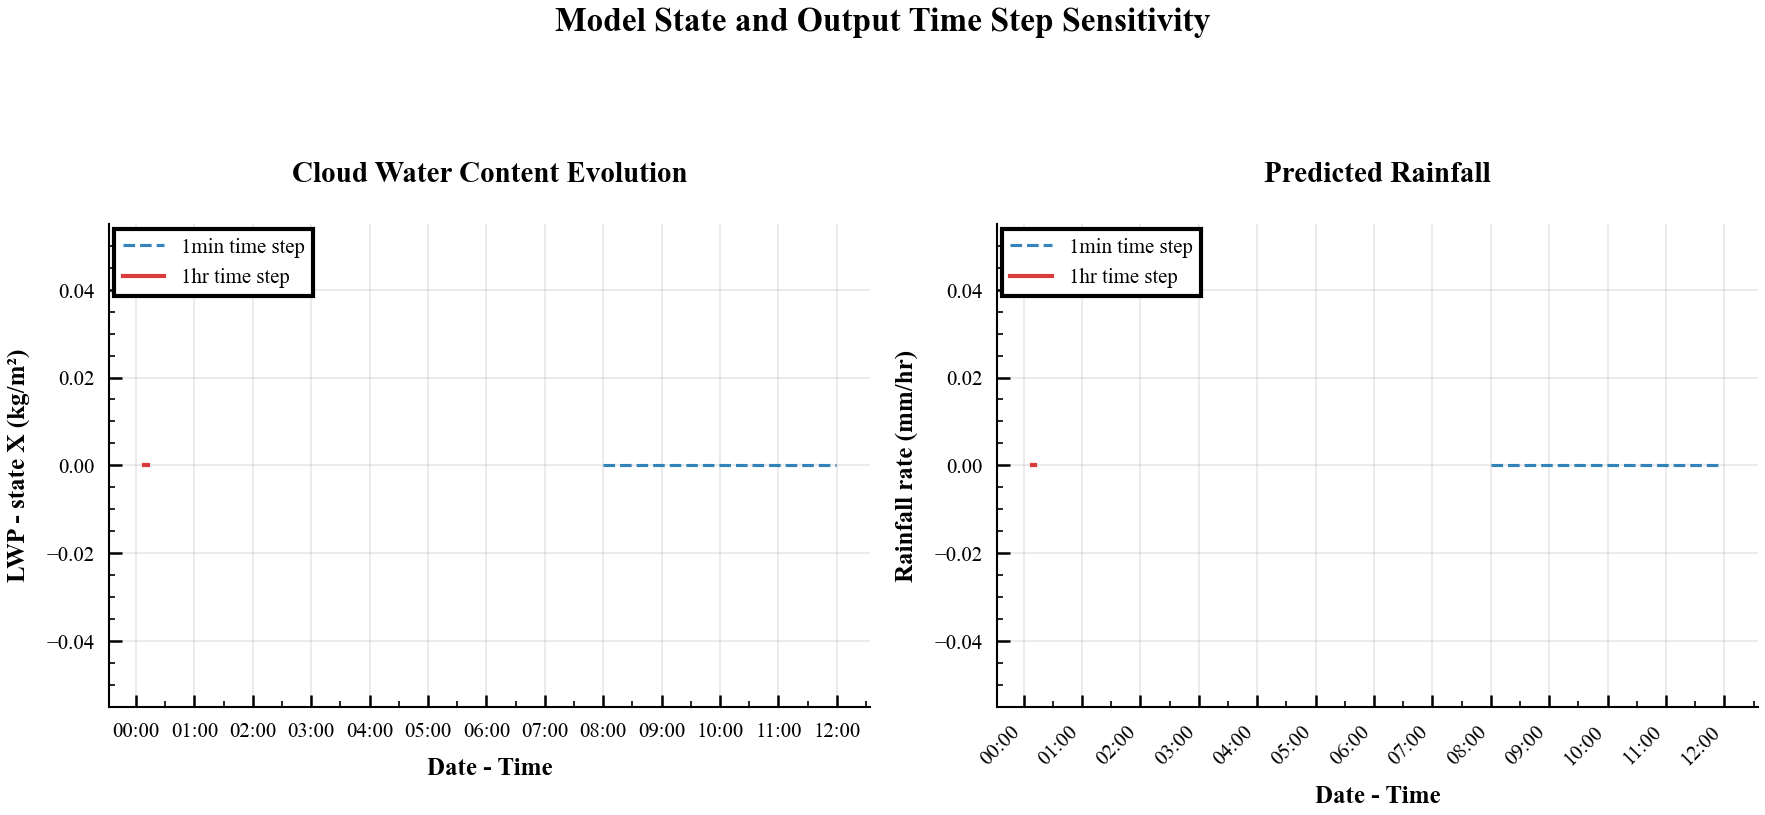

In [ ]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.
ratio_series = (X_n_series.T / Z_c_new[8:12]).T * 1000
# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure with two subplots - scaled by SCALE_FACTOR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12 * SCALE_FACTOR, 5* SCALE_FACTOR), 
                               sharex=True)

# Scientific color palette (colorblind-friendly)
colors = {
    'ambient': '#1f77b4',      # Blue
    'no_entrainment': '#d62728',  # Red  
    'with_entrainment': '#ff7f0e'  # Orange
}

# ==================== SUBPLOT 1: LWC (Cloud Water Content) ====================
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_model_lwc = ax1.plot(time_downscale[:-1], X_n_series.reshape(-1),  # Convert to g/m³
                          color=colors['ambient'], 
                          label='1min time step',
                          linestyle='--', 
                          linewidth=1.5 * SCALE_FACTOR,
                          alpha=0.9)

line_downscaled_lwc = ax1.plot(time[8:13], X[8:13],
                               color=colors['no_entrainment'], 
                               label='1hr time step',
                               linestyle='-', 
                               linewidth=2.0 * SCALE_FACTOR,
                               alpha=0.9)

# Scientific axis labels with units
ax1.set_ylabel('LWP - state X (kg/m²)', fontweight='bold')
ax1.set_xlabel('Date - Time', fontweight='bold')
ax1.set_title('Cloud Water Content Evolution',
              fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax1.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()

# Scientific legend positioning
legend1 = ax1.legend(loc='upper left',
                     frameon=True,
                     framealpha=1.0,
                     edgecolor='black',
                     facecolor='white',
                     borderaxespad=0.5 * SCALE_FACTOR,
                     ncol=1)

# Tick parameters - scaled by SCALE_FACTOR
ax1.tick_params(which='major', 
                length=6 * SCALE_FACTOR, 
                width=1.2 * SCALE_FACTOR)
ax1.tick_params(which='minor', 
                length=3 * SCALE_FACTOR, 
                width=0.8 * SCALE_FACTOR)

# ==================== SUBPLOT 2: Rainfall Rate ====================
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_model_rain = ax2.plot(time_downscale[:-1], R_n_series*3600,  # Convert to mm/hr
                           color=colors['ambient'], 
                           label='1min time step',
                           linestyle='--', 
                           linewidth=1.5 * SCALE_FACTOR,
                           alpha=0.9)

line_downscaled_rain = ax2.plot(time[8:13], R[8:13]*3600,
                                color=colors['no_entrainment'], 
                                label='1hr time step',
                                linestyle='-', 
                                linewidth=2.0 * SCALE_FACTOR,
                                alpha=0.9)

# Scientific axis labels with units
ax2.set_ylabel('Rainfall rate (mm/hr)', fontweight='bold')
ax2.set_xlabel('Date - Time', fontweight='bold')
ax2.set_title('Predicted Rainfall',
              fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax2.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax2.set_axisbelow(True)

# Minor ticks for precision
ax2.minorticks_on()

# Scientific legend positioning
legend2 = ax2.legend(loc='upper left',
                     frameon=True,
                     framealpha=1.0,
                     edgecolor='black',
                     facecolor='white',
                     borderaxespad=0.5 * SCALE_FACTOR,
                     ncol=1)

# Tick parameters - scaled by SCALE_FACTOR
ax2.tick_params(which='major', 
                length=6 * SCALE_FACTOR, 
                width=1.2 * SCALE_FACTOR)
ax2.tick_params(which='minor', 
                length=3 * SCALE_FACTOR, 
                width=0.8 * SCALE_FACTOR)

# ==================== SHARED X-AXIS FORMATTING ====================
# Professional tick formatting (only on bottom subplot)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Adjust format as needed
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=1))

# Minor ticks every 30 minutes
ax2.xaxis.set_minor_locator(mdates.MinuteLocator(interval=30))

# Rotate labels with scaled font size and better spacing
plt.setp(ax2.xaxis.get_majorticklabels(), 
         rotation=45,  # Adjust rotation as needed
         ha='right', 
         fontsize=10*SCALE_FACTOR)

# Optional: Add overall figure title
fig.suptitle('Model State and Output Time Step Sensitivity',
             fontweight='bold', 
             fontsize=16*SCALE_FACTOR, 
             y=1.1)

# Adjust spacing between subplots
plt.subplots_adjust(hspace=2, top=3)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

In [ ]:
X_n_final

3.0000000000000028e-05

In [ ]:
X_new = np.zeros(60)
n = 2
dt_time = 3600
X_new[0] = X0
for i in range(1,n):
    X_new[i] = X_series(Z_c_mean,f_arr_mean,X0,X_n_series[i-1],i,dt_time)
print(X_new)

NameError: name 'X0' is not defined

In [ ]:
Z_c_new[12] - Z_c_new[11]

-917.6877254373744

In [ ]:
f_arr_mean*dt_time

60.71203176708574

In [ ]:
dt_seconds

array([3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600.,
       3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600.,
       3600., 3600., 3600., 3600., 3600.])

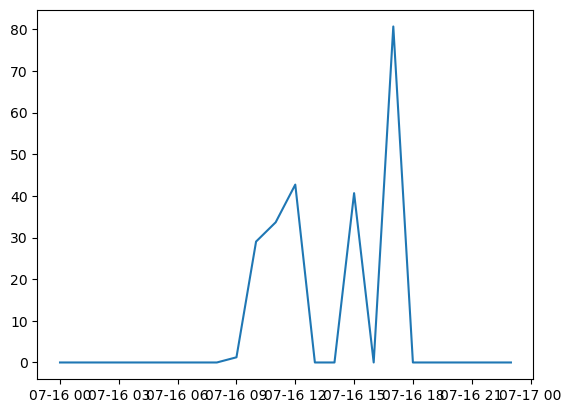

In [ ]:
plt.plot(time,X)
plt.show()

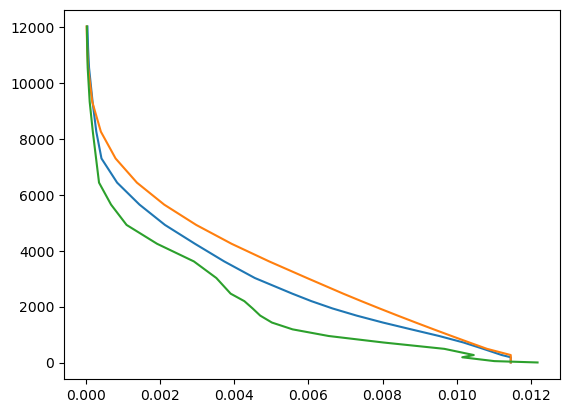

In [ ]:
index = 2
#plt.plot(w_sat(T_d[index],p_new[index,0]) - q_v_parcel[index],Z_new[index],label='T_v_moist')
plt.plot(q_v_parcel_new[index],Z_new[index],label='q_l'   )
plt.plot(q_v_parcel[index],Z_new[index],label='q_v_parcel')
plt.plot(q_v_new[index],Z_new[index],label='q_v')
plt.show()

#### LWC and LWP(state)

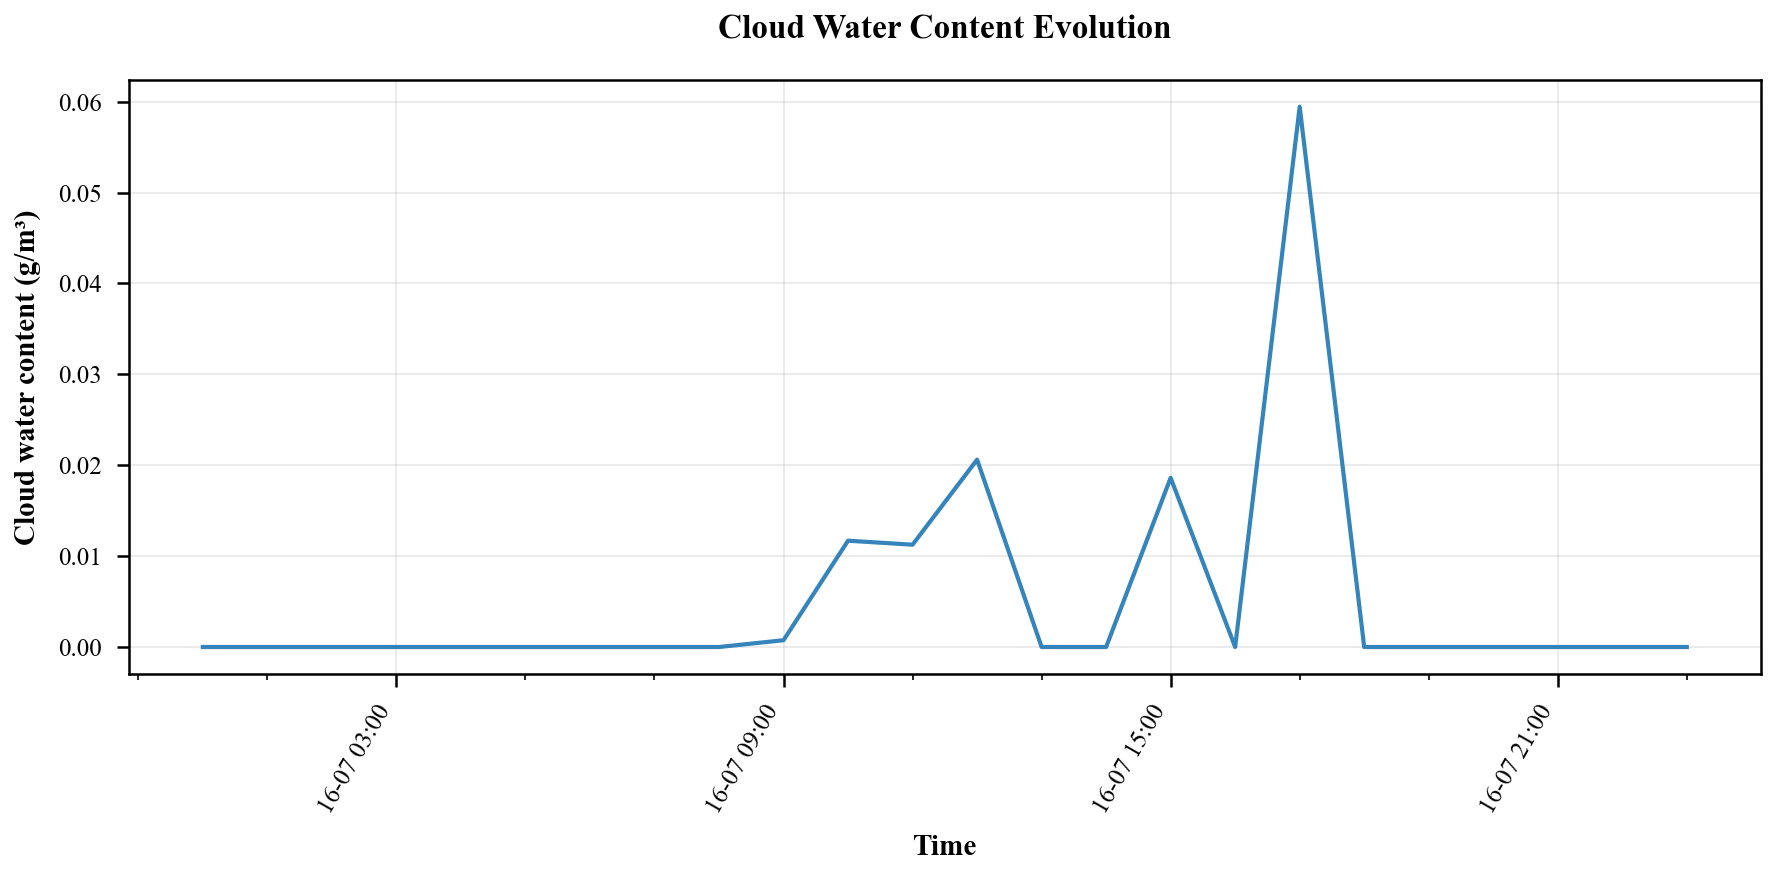

In [ ]:
import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Plot with scaled line widths
ax.plot(time_dt, X / Z_c_new,
        color='#1f77b4',  # Default blue
        linewidth=2.0 * SCALE_FACTOR,
        alpha=0.9)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Cloud water content (g/m³)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Cloud Water Content Evolution',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Optional: Uncomment to set y-axis limits
#ax.set_ylim(0, 10)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

In [ ]:
time_dt

DatetimeIndex(['2024-07-16 00:00:00', '2024-07-16 01:00:00',
               '2024-07-16 02:00:00', '2024-07-16 03:00:00',
               '2024-07-16 04:00:00', '2024-07-16 05:00:00',
               '2024-07-16 06:00:00', '2024-07-16 07:00:00',
               '2024-07-16 08:00:00', '2024-07-16 09:00:00',
               '2024-07-16 10:00:00', '2024-07-16 11:00:00',
               '2024-07-16 12:00:00', '2024-07-16 13:00:00',
               '2024-07-16 14:00:00', '2024-07-16 15:00:00',
               '2024-07-16 16:00:00', '2024-07-16 17:00:00',
               '2024-07-16 18:00:00', '2024-07-16 19:00:00',
               '2024-07-16 20:00:00', '2024-07-16 21:00:00',
               '2024-07-16 22:00:00', '2024-07-16 23:00:00'],
              dtype='datetime64[ns]', freq=None)

In [ ]:
from scipy import stats
stats.pearsonr(R*3600, hourly_avg)

NameError: name 'hourly_avg' is not defined

In [ ]:
from scipy import stats
stats.pearsonr(R*3600, hourly_acc)

In [ ]:
time_dt

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create the plot with improved styling
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data with cleaner formatting
ax.plot(time, P * 3600, label='Model output', 
        color='blue', linewidth=2, alpha=0.8)
ax.plot(time, hourly_acc[:-11]/5, label='Accumulated precipitation Disdrometer', 
        color='red', linewidth=2, alpha=0.8)

# Add labels and title
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Precipitation (mm/hour)', fontsize=12)
ax.set_title('Hourly Accumulated Precipitation', fontsize=14, fontweight='bold')

# Format x-axis with dates
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(),
         rotation=rotation,
         ha='right',
         fontsize=12 * SCALE_FACTOR)

# Customize the legend
ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--')

# Adjust layout and show
plt.tight_layout()
plt.show()